# Adoc ROOT File Basic Read, Analysis, and ETL

Use this notebook for manually downloaded ROOT files placed in `data/adoc/`. It performs a small, memory-safe NanoAOD workflow: discover a local file, inspect the `Events` tree, read selected branches in a small batch, plot muon pT, and write selected branches to Parquet.

In [1]:
from pathlib import Path
import sys

WORKSPACE = Path.cwd()
if not (WORKSPACE / 'src').exists():
    WORKSPACE = WORKSPACE.parent

sys.path.insert(0, str(WORKSPACE))

ADOC_DIR = WORKSPACE / 'data' / 'adoc'
PARQUET_DIR = WORKSPACE / 'data' / 'parquet' / 'adoc_test'
OUTPUT_DIR = WORKSPACE / 'outputs'

ADOC_DIR.mkdir(parents=True, exist_ok=True)
PARQUET_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Workspace:', WORKSPACE)
print('Adoc input folder:', ADOC_DIR)

Workspace: c:\Ewok\Abomination\Theory of E\V-TRY\ColliderLake
Adoc input folder: c:\Ewok\Abomination\Theory of E\V-TRY\ColliderLake\data\adoc


## 1. Select a Manual ROOT File

Place one or more manually downloaded `.root` files in `data/adoc/`. The next cell picks the first one. You can override `root_file` manually if needed.

In [2]:
root_files = sorted(ADOC_DIR.glob('*.root'))
if not root_files:
    raise FileNotFoundError(f'No .root files found in {ADOC_DIR}. Place a test ROOT file there first.')

root_file = root_files[0]
root_file

WindowsPath('c:/Ewok/Abomination/Theory of E/V-TRY/ColliderLake/data/adoc/576759DA-4A35-534B-B926-2A9E4A5A7268.root')

## 2. Inspect ROOT Contents

NanoAOD analysis usually starts from the `Events` TTree. This cell lists top-level objects and a small branch preview without loading all event data.

In [3]:
import uproot

root = uproot.open(root_file)
root.classnames()

{'tag;1': 'TObjString',
 'Events;1': 'TTree',
 'LuminosityBlocks;1': 'TTree',
 'Runs;1': 'TTree',
 'MetaData;1': 'TTree',
 'ParameterSets;1': 'TTree'}

In [6]:
events = root['Events']
print('Entries:', events.num_entries)
branches = list(events.keys())
print('Branch count:', len(branches))
branches[:50000]

Entries: 56141
Branch count: 1346


['run',
 'luminosityBlock',
 'event',
 'nboostedTau',
 'boostedTau_chargedIso',
 'boostedTau_eta',
 'boostedTau_leadTkDeltaEta',
 'boostedTau_leadTkDeltaPhi',
 'boostedTau_leadTkPtOverTauPt',
 'boostedTau_mass',
 'boostedTau_neutralIso',
 'boostedTau_phi',
 'boostedTau_photonsOutsideSignalCone',
 'boostedTau_pt',
 'boostedTau_puCorr',
 'boostedTau_rawAntiEle2018',
 'boostedTau_rawIso',
 'boostedTau_rawIsodR03',
 'boostedTau_rawMVAnewDM2017v2',
 'boostedTau_rawMVAoldDM2017v2',
 'boostedTau_rawMVAoldDMdR032017v2',
 'boostedTau_charge',
 'boostedTau_decayMode',
 'boostedTau_jetIdx',
 'boostedTau_rawAntiEleCat2018',
 'boostedTau_idAntiEle2018',
 'boostedTau_idAntiMu',
 'boostedTau_idMVAnewDM2017v2',
 'boostedTau_idMVAoldDM2017v2',
 'boostedTau_idMVAoldDMdR032017v2',
 'CaloMET_phi',
 'CaloMET_pt',
 'CaloMET_sumEt',
 'ChsMET_phi',
 'ChsMET_pt',
 'ChsMET_sumEt',
 'nCorrT1METJet',
 'CorrT1METJet_area',
 'CorrT1METJet_eta',
 'CorrT1METJet_muonSubtrFactor',
 'CorrT1METJet_phi',
 'CorrT1METJet_ra

## 3. Read a Small Selected Batch

Only the selected branches are read. `entry_stop` is intentionally small for first-pass exploration.

In [12]:
import awkward as ak
import numpy as np

selected_branches = ['Muon_pt', 'Muon_eta', 'Muon_phi', 'Muon_mass', 'MET_pt', 'Jet_pt']

available_branches = branches
missing_branches = sorted(set(selected_branches) - set(available_branches))

print('Available:', available_branches)
print('Missing:', missing_branches)

arrays = events.arrays(available_branches, entry_stop=1000, library='ak')
arrays.fields

Available: ['run', 'luminosityBlock', 'event', 'nboostedTau', 'boostedTau_chargedIso', 'boostedTau_eta', 'boostedTau_leadTkDeltaEta', 'boostedTau_leadTkDeltaPhi', 'boostedTau_leadTkPtOverTauPt', 'boostedTau_mass', 'boostedTau_neutralIso', 'boostedTau_phi', 'boostedTau_photonsOutsideSignalCone', 'boostedTau_pt', 'boostedTau_puCorr', 'boostedTau_rawAntiEle2018', 'boostedTau_rawIso', 'boostedTau_rawIsodR03', 'boostedTau_rawMVAnewDM2017v2', 'boostedTau_rawMVAoldDM2017v2', 'boostedTau_rawMVAoldDMdR032017v2', 'boostedTau_charge', 'boostedTau_decayMode', 'boostedTau_jetIdx', 'boostedTau_rawAntiEleCat2018', 'boostedTau_idAntiEle2018', 'boostedTau_idAntiMu', 'boostedTau_idMVAnewDM2017v2', 'boostedTau_idMVAoldDM2017v2', 'boostedTau_idMVAoldDMdR032017v2', 'CaloMET_phi', 'CaloMET_pt', 'CaloMET_sumEt', 'ChsMET_phi', 'ChsMET_pt', 'ChsMET_sumEt', 'nCorrT1METJet', 'CorrT1METJet_area', 'CorrT1METJet_eta', 'CorrT1METJet_muonSubtrFactor', 'CorrT1METJet_phi', 'CorrT1METJet_rawPt', 'DeepMETResolutionTune_p

['run',
 'luminosityBlock',
 'event',
 'nboostedTau',
 'boostedTau_chargedIso',
 'boostedTau_eta',
 'boostedTau_leadTkDeltaEta',
 'boostedTau_leadTkDeltaPhi',
 'boostedTau_leadTkPtOverTauPt',
 'boostedTau_mass',
 'boostedTau_neutralIso',
 'boostedTau_phi',
 'boostedTau_photonsOutsideSignalCone',
 'boostedTau_pt',
 'boostedTau_puCorr',
 'boostedTau_rawAntiEle2018',
 'boostedTau_rawIso',
 'boostedTau_rawIsodR03',
 'boostedTau_rawMVAnewDM2017v2',
 'boostedTau_rawMVAoldDM2017v2',
 'boostedTau_rawMVAoldDMdR032017v2',
 'boostedTau_charge',
 'boostedTau_decayMode',
 'boostedTau_jetIdx',
 'boostedTau_rawAntiEleCat2018',
 'boostedTau_idAntiEle2018',
 'boostedTau_idAntiMu',
 'boostedTau_idMVAnewDM2017v2',
 'boostedTau_idMVAoldDM2017v2',
 'boostedTau_idMVAoldDMdR032017v2',
 'CaloMET_phi',
 'CaloMET_pt',
 'CaloMET_sumEt',
 'ChsMET_phi',
 'ChsMET_pt',
 'ChsMET_sumEt',
 'nCorrT1METJet',
 'CorrT1METJet_area',
 'CorrT1METJet_eta',
 'CorrT1METJet_muonSubtrFactor',
 'CorrT1METJet_phi',
 'CorrT1METJet_ra

## 4. Basic Analysis

Flatten jagged muon arrays and compute quick batch-level summaries.

In [13]:
muon_pt = ak.to_numpy(ak.flatten(arrays['Muon_pt'], axis=None)) if 'Muon_pt' in arrays.fields else np.array([])

summary = {
    'events_read': len(arrays),
    'muons_read': len(muon_pt),
    'muon_pt_mean': float(np.mean(muon_pt)) if len(muon_pt) else None,
    'muon_pt_max': float(np.max(muon_pt)) if len(muon_pt) else None,
}
summary

{'events_read': 1000,
 'muons_read': 1299,
 'muon_pt_mean': 32.99355697631836,
 'muon_pt_max': 761.5211181640625}

WindowsPath('c:/Ewok/Abomination/Theory of E/V-TRY/ColliderLake/outputs/adoc_muon_pt.png')

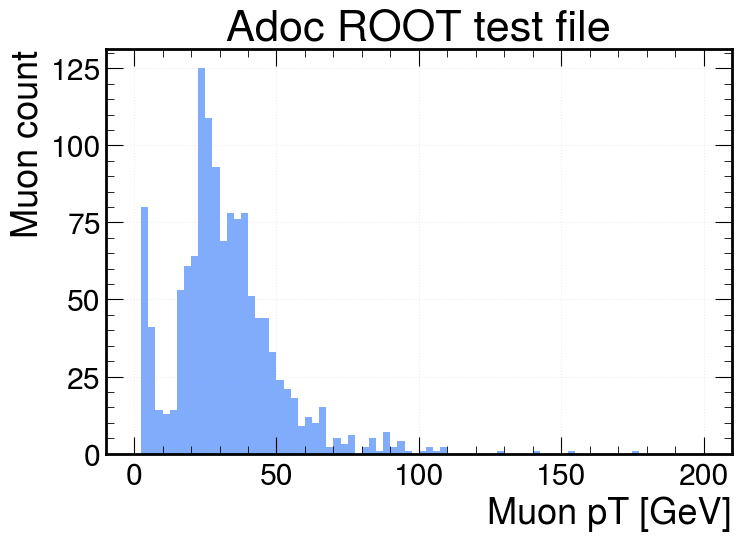

In [14]:
import matplotlib.pyplot as plt
import mplhep as hep

plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(muon_pt, bins=80, range=(0, 200), histtype='stepfilled', alpha=0.75)
ax.set_xlabel('Muon pT [GeV]')
ax.set_ylabel('Muon count')
ax.set_title('Adoc ROOT test file')
ax.grid(alpha=0.2)
fig.tight_layout()

plot_path = OUTPUT_DIR / 'adoc_muon_pt.png'
fig.savefig(plot_path, dpi=160)
plot_path

## 5. ETL to Parquet

This converts selected NanoAOD branches into Parquet parts using chunked `uproot.iterate`. Keep `max_batches` small while testing.

In [16]:
import awkward as ak

written = []
max_batches = 2

for batch_index, batch in enumerate(events.iterate(available_branches, step_size='25 MB', library='ak')):
    if batch_index >= max_batches:
        break
    output_path = PARQUET_DIR / f'{root_file.stem}_part_{batch_index:04d}.parquet'
    ak.to_parquet(batch, output_path)
    written.append(output_path)

written

[WindowsPath('c:/Ewok/Abomination/Theory of E/V-TRY/ColliderLake/data/parquet/adoc_test/576759DA-4A35-534B-B926-2A9E4A5A7268_part_0000.parquet'),
 WindowsPath('c:/Ewok/Abomination/Theory of E/V-TRY/ColliderLake/data/parquet/adoc_test/576759DA-4A35-534B-B926-2A9E4A5A7268_part_0001.parquet')]

## 6. Verify Parquet Output

Read one part back with pandas for a quick sanity check. Jagged NanoAOD columns remain nested/list-like.

In [17]:
import pandas as pd

if written:
    df = pd.read_parquet(written[0])
    display(df.head())
    print(df.dtypes)
else:
    print('No Parquet files were written.')

,run,luminosityBlock,event,nboostedTau,boostedTau_chargedIso,boostedTau_eta,boostedTau_leadTkDeltaEta,boostedTau_leadTkDeltaPhi,boostedTau_leadTkPtOverTauPt,boostedTau_mass,...,HLT_PFMET400,HLT_PFMET500,HLT_PFMET600,HLT_Ele250_CaloIdVT_GsfTrkIdT,HLT_Ele300_CaloIdVT_GsfTrkIdT,HLT_HT2000,HLT_HT2500,HLT_IsoTrackHE,HLT_IsoTrackHB,HLTriggerFinalPath
0,283830,15,27910912,0,[],[],[],[],[],[],...,False,False,False,False,False,False,False,False,False,False
1,283830,15,27861269,0,[],[],[],[],[],[],...,False,False,False,False,False,False,False,False,False,False
2,283830,15,28246124,0,[],[],[],[],[],[],...,False,False,False,False,False,False,False,False,False,False
3,283830,15,28112385,0,[],[],[],[],[],[],...,False,False,False,False,False,False,False,False,False,False
4,283830,15,27809878,0,[],[],[],[],[],[],...,False,False,False,False,False,False,False,False,False,False


run                      uint32
luminosityBlock          uint32
event                    uint64
nboostedTau              uint32
boostedTau_chargedIso    object
                          ...  
HLT_HT2000                 bool
HLT_HT2500                 bool
HLT_IsoTrackHE             bool
HLT_IsoTrackHB             bool
HLTriggerFinalPath         bool
Length: 1346, dtype: object
